# Random forest classifier for landcover classification from remote sensing images

In this tasks, we will use a portion of the [SAT-6](https://csc.lsu.edu/~saikat/deepsat/) dataset from Louisiana State University and NASA Ames Research Center.

For this demonstration, we only use the test dataset, which consists of 81000 samples randomly distributed across 6 landcover classes.

In [37]:
# Random forest classifier for landcover classification
# Author: Ankit Patnala, JSC, 2025; updated by Martin Schultz, April 2026
# Download necessary packages if right kernel is not present
# Not needed in colab
#!pip install pandas
#!pip install scikit-learn
#!pip install matplotlib

In [38]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from collections import Counter
from time import perf_counter
import numpy as np


## Obtaining the data
The data is available via this B2share link [link](https://b2share.eudat.eu/records/89654eac10724d30a6c7e51f2c5422de). Download all the files at the same folder path where you are creating this notebook

Alternatively use the following wget commands to download the data

The following cell can be executed in Google colab

In [39]:
!mkdir -p data
!wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/X_test_sat6.csv
!wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/y_test_sat6.csv
!wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/sat6annotations.csv
# Note that `cd data`, ..., `cd ..` doesn't work

--2026-06-04 11:21:01--  https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/X_test_sat6.csv
Resolving b2share.eudat.eu (b2share.eudat.eu)... 86.50.166.117, 2001:708:10:6802::12
Connecting to b2share.eudat.eu (b2share.eudat.eu)|86.50.166.117|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/2p6ra-xfj86/files/X_test_sat6.csv [following]
--2026-06-04 11:21:02--  https://b2share.eudat.eu/records/2p6ra-xfj86/files/X_test_sat6.csv
Reusing existing connection to b2share.eudat.eu:443.
HTTP request sent, awaiting response... 200 OK
Length: 905628829 (864M) [text/plain]
Saving to: ‘data/X_test_sat6.csv.1’

X_test_sat6.csv.1   100%[===================>] 863.67M  17.7MB/s    in 43s     

2026-06-04 11:21:46 (19.9 MB/s) - ‘data/X_test_sat6.csv.1’ saved [905628829/905628829]

--2026-06-04 11:21:46--  https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/y_test_sat6.csv
Resolving b2share.eudat.eu (b2share.eudat.e

In [40]:
# load the csv file with the image data. Each row belongs to one sample. Each sample has 3136 columns i.e. 4 channels (R,G,B, and NIR) and 28 \times 28 spatial size
landcover_df = pd.read_csv("./data/X_test_sat6.csv",header=None)

In [41]:
#print(type(landcover_df))

In [42]:
if 0:
# test if data is of the shape [RGBNIR,RGBNIR,RGBNIR,...]

  sample = landcover_df.iloc[1000].values #print(sample.shape)
  img = sample.reshape(28, 28,4) # data is of the shape [RGBNIR,RGBNIR,RGBNIR,...]

  R   = img[:,:,0]
  G   = img[:,:,1]
  B   = img[:,:,2]
  NIR = img[:,:,3]

  rgb = np.stack([R, G, B], axis=-1) # in visual colors to check the matrix flattening

  plt.figure(figsize=(4,4))
  plt.imshow(rgb.astype(np.uint8))
  # plt.imshow(data[0, ..., :3].astype(np.uint8))
  plt.title("RGB reconstruction")
  plt.axis("off")
  plt.show()

  # Visualize the four channels:

  fig, axes = plt.subplots(1, 4, figsize=(16,4))

  axes[0].imshow(R, cmap='Reds')
  axes[0].set_title("Red")

  axes[1].imshow(G, cmap='Greens')
  axes[1].set_title("Green")

  axes[2].imshow(B, cmap='Blues')
  axes[2].set_title("Blue")

  axes[3].imshow(NIR, cmap='gray')
  axes[3].set_title("NIR")

  for ax in axes:
      ax.axis("off")

  plt.show()

&#x1F479;  _Task:_ Make sure you understand this data structure.

&#x1F479;  _Question:_ What would you need to do to extract only the green and the infrared channel from this data? _Answer:_ G   = img[:,:,1], etc. One sample in the data has format RGBNIR,RGBNIR,...

In [43]:
# Read the annotation file to get the annotation i.e. classname corresponding to the labels
annotations = pd.read_csv("./data/sat6annotations.csv", header=None)
print(annotations)
labels = annotations[0].values
print(f'class labels: {labels}')

             0  1  2  3  4  5  6
0     building  1  0  0  0  0  0
1  barren_land  0  1  0  0  0  0
2        trees  0  0  1  0  0  0
3    grassland  0  0  0  1  0  0
4         road  0  0  0  0  1  0
5        water  0  0  0  0  0  1
class labels: ['building' 'barren_land' 'trees' 'grassland' 'road' 'water']


The data structure that you see above is called _one-hot encoding_

&#x1F479; _Question:_ What is the advantage of this encoding compared to a simple class label like '0', '1', '2', '3', '4', '5', or text labels like 'building', 'barren_land', ...?

_Answer:_ ML algorithms operate on numerical data, so class labels must be encoded numerically rather than as text. Numerical encoding is also more memory-efficient and computationally faster than string labels.

One-hot encoding prevents the model from interpreting class labels as ordinal values. For example, labels 0,1,2,3,4,5 may incorrectly imply that class 5 is “larger” or “closer” to class 4 than to class 1, although the classes are actually categorical and unordered.

In [44]:
# load the csv file with the labels of all samples
labels_df = pd.read_csv("./data/y_test_sat6.csv",header=None)
print(labels_df)
# get the names of the class labels (here, only "0" to "5")
# These correspond to the labels printed above
column_names = labels_df.columns.values


       0  1  2  3  4  5
0      0  0  1  0  0  0
1      0  0  1  0  0  0
2      0  0  0  0  0  1
3      0  1  0  0  0  0
4      0  0  0  0  0  1
...   .. .. .. .. .. ..
80995  0  0  0  0  0  1
80996  0  1  0  0  0  0
80997  0  0  1  0  0  0
80998  0  0  0  0  0  1
80999  0  0  1  0  0  0

[81000 rows x 6 columns]


# Plot random samples for illustration

&#x1F479; _Task:_ Make sure you understand the following code for creating balanced samples from the overall dataset and the reshaping of ther data that is needed for plotting.

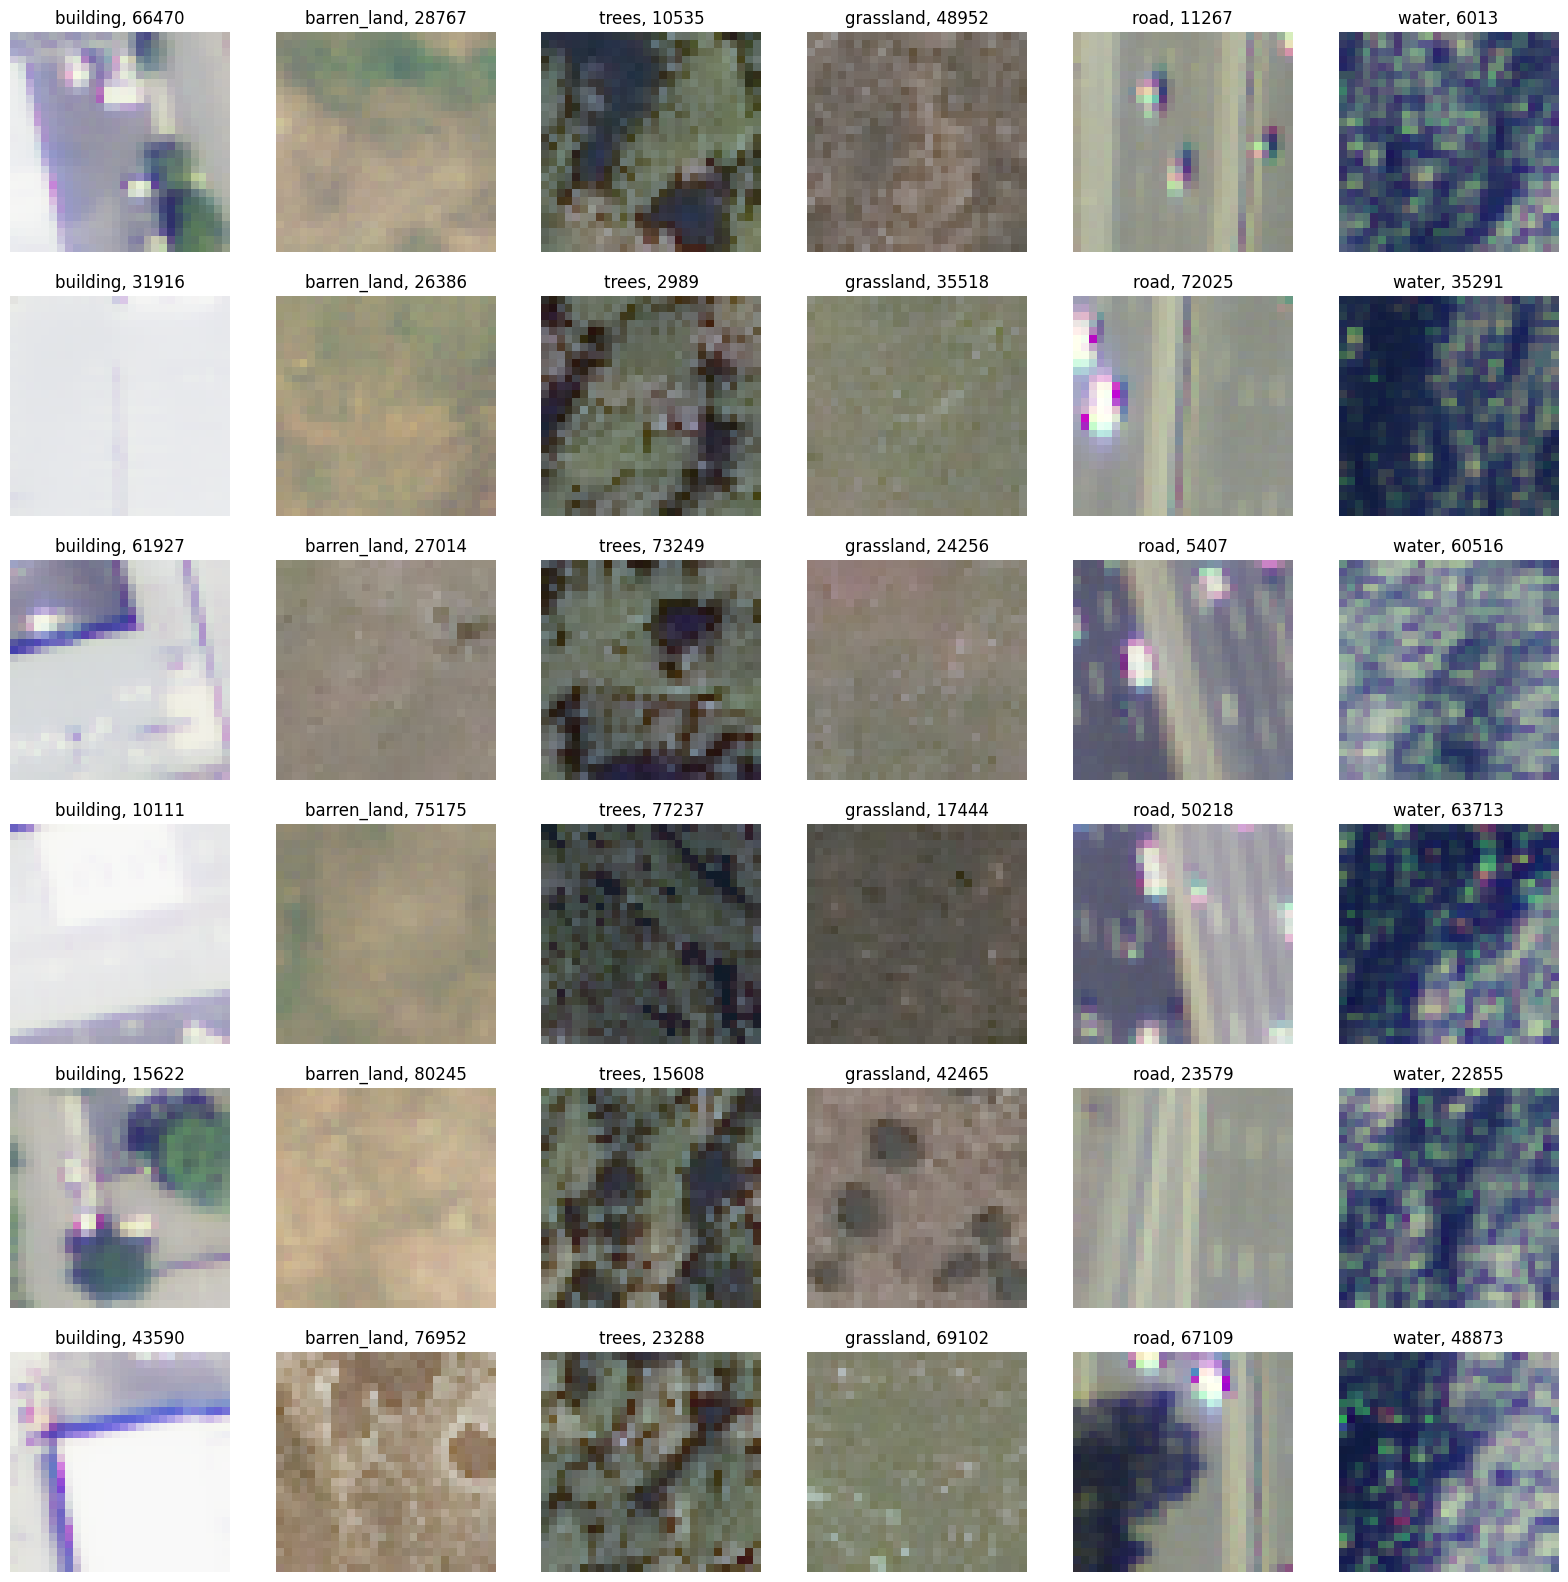

In [45]:
num_classes = len(column_names)
num_samples = 6  # number of rows to plot
sample_idx = []
for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    # randomly select num_samples from this index list - make sure to avoid duplicates
    sample_idx.append(np.random.choice(np.where(class_idx.values)[0], size=num_samples, replace=False).tolist())

fig, ax = plt.subplots(num_samples, num_classes, figsize=(20,20))
for i in range(num_samples):
    for j in range(num_classes):
        data_index = sample_idx[j][i]
        ax[i,j].set_title(f"{labels[j]}, {data_index}")
        ax[i,j].axis('off')
        data = np.reshape(landcover_df.iloc[data_index].values,(-1,28,28,4))
        ax[i,j].imshow(data[0,...,:3])

plt.show()

### Create the training and test datasets

Collect equal number of samples **from each class** for training and testing, respectively

In [46]:
# num_train = 1000
# num_test = 100
# train_idx = []
# test_idx = []
# for column in column_names:
#     # find all indices of a given class
#     class_idx = labels_df[column] == 1
#     # randomly select num_train and num_test values from this index list - make sure to avoid duplicates
#     train_idx.extend(np.random.choice(np.where(class_idx.values)[0], size=num_train, replace=False).tolist())
#     test_idx.extend(np.random.choice(np.where(class_idx.values)[0], size=num_test, replace=False).tolist())
# print(f'number of train indices: {len(train_idx)}, number of test indices: {len(test_idx)}')


&#x1F479;  _Question:_ Why use `extend`here and `append` above? _Answer:_ need a vector, not a nested array

&#x1F479;  _Question:_ What is wrong with the above code? _Answer:_ there is an overlap possible for a data between the train and test samples -> consider overfitting.

In [47]:
# correct the code above:

num_train = 1000
num_test = 100
num_all = num_train + num_test
train_idx = []
test_idx = []
for column in column_names:
    class_idx = labels_df[column] == 1   # find all indices of a given class
    indices = np.where(class_idx.values)[0] # booleen to numbers
    selected_idx = np.random.choice(indices, size=num_all, replace=False)

    train_idx.extend(selected_idx[:num_train].tolist())
    test_idx.extend(selected_idx[num_train:].tolist())

print(f'number of train indices: {len(train_idx)}')
print(f'number of test indices: {len(test_idx)}')

overlap = set(train_idx).intersection(set(test_idx))
print(f'overlap between train and test: {len(overlap)}')

number of train indices: 6000
number of test indices: 600
overlap between train and test: 0


In [48]:
# Shuffle train and test indices
train_idx = np.random.permutation(train_idx)
test_idx = np.random.permutation(test_idx)
# Extract images and labels corresponding to the selected indices
X_train = landcover_df.iloc[train_idx]
y_train = labels_df.iloc[train_idx]
X_test = landcover_df.iloc[test_idx]
y_test = labels_df.iloc[test_idx]

&#x1F479; _Question:_ Why do you want to shuffle the samples in the train and test datasets? _Answer:_ to avoid data ordering by class

## Rewrite the code to allow for the easy reorganization of data when doing experiments

##

## 1. Add NDVI to the data as a fifth channel

In [49]:
DEFAULT_CONFIG = {
    "image_height": 28,
    "image_width": 28,

    "n_train_per_class": 1000,
    "n_test_per_class": 100,
    #"n_channels": 4, # R, G, B, NIR
    "random_state": 42
}

In [50]:

# compute NDVI and add to the X data matrix:
def flat_to_images(X_flat, config, n_channels=4):
    # original data is flattened, convert to [28,28,4] images
    X_flat = np.asarray(X_flat)
    return X_flat.reshape(-1,config["image_height"],config["image_width"],n_channels)

def add_ndvi(X_flat, config):
  # compute flattened NDVI from RGB+NIR data
  images = flat_to_images(X_flat, config).astype(np.float32)

  red = images[:,:,:,0]
  nir = images[:,:,:,3]

  ndvi = (nir - red) / (nir + red + 1e-6)
  ndvi = ndvi[..., np.newaxis]

  images_5ch = np.concatenate([images, ndvi],axis=3)

  ndvi_flat = images_5ch.reshape(len(X_flat),-1)
  return ndvi_flat


In [51]:
# Plot all the channels for one sample:

def plot_sample_channels(X_flat, config, sample_index=0, has_ndvi=False):
    """
    Plot one sample to check whether reshaping is correct.

    Works for:
        RGB+NIR data:        (n_samples, 28*28*4)
        RGB+NIR+NDVI data:   (n_samples, 28*28*5)

    Parameters
    ----------
    sample_index : int  (Sample number)
    has_ndvi : bool
        False -> reshape to (28,28,4)
        True  -> reshape to (28,28,5)
    """

    if isinstance(X_flat, pd.DataFrame):
        X_flat = X_flat.values

    n_channels = 5 if has_ndvi else 4

    img = X_flat[sample_index].reshape(config["image_height"],config["image_width"],n_channels)

    R = img[:, :, 0]
    G = img[:, :, 1]
    B = img[:, :, 2]
    NIR = img[:, :, 3]

    rgb = np.stack([R, G, B], axis=-1)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.ravel()

    # RGB reconstruction
    axes[0].imshow(rgb.astype(np.uint8))
    axes[0].set_title("RGB")

    # Individual channels
    axes[1].imshow(R, cmap="Reds")
    axes[1].set_title("Red")

    axes[2].imshow(G, cmap="Greens")
    axes[2].set_title("Green")

    axes[3].imshow(B, cmap="Blues")
    axes[3].set_title("Blue")

    axes[4].imshow(NIR, cmap="gray")
    axes[4].set_title("NIR")

    if has_ndvi:
        NDVI = img[:, :, 4]

        im = axes[5].imshow(NDVI,cmap="RdYlGn",vmin=-1,vmax=1        )
        axes[5].set_title("NDVI")
    else:
        axes[5].axis("off")
    for ax in axes:
        ax.axis("off")

    plt.suptitle(f"Sample {sample_index}")
    plt.tight_layout()
    plt.show()

## 2. For Random Forest experiments use selective channels

Run experiments with different channel combinations:

1) RGB+NIR
2) RGB+NIR+NDVI
3) RGB
4) RG+NIR

In [52]:
# allows for selective combination of channels:

def select_channels(X_flat, config, channels=("R", "G", "B", "NIR", "NDVI")):

    channel_map = {"R": 0,"G": 1,"B": 2,"NIR": 3,"NDVI": 4}
    channel_indices = [channel_map[ch] for ch in channels]

    # important: infer whether input has 4 or 5 channels
    n_features = X_flat.shape[1]
    pixels = config["image_height"] * config["image_width"]
    n_channels = n_features // pixels

    images = flat_to_images(X_flat, config, n_channels=n_channels)
    selected = images[:, :, :, channel_indices]

    return selected.reshape(len(X_flat), -1)

#-------------------------------------------------------------------------
# For random forest the best is to use the same number of data samples for each
# landscape class, e.g. n_train_per_class= 1000 samples in each class in a training set:
#-------------------------------------------------------------------------

def create_balanced_split(X, y, config):
    """
    Create balanced train/test split.

    For each class:
    - randomly select n_train_per_class + n_test_per_class samples
    - first part goes to train
    - second part goes to test
    """
    rng = np.random.default_rng(config["random_state"])

    train_idx = []
    test_idx = []

    n_train = config["n_train_per_class"]
    n_test = config["n_test_per_class"]
    n_total = n_train + n_test

    # maybe y.columns.values?
    for column in range(y.shape[1]):
        class_mask = y[:, column] == 1
        class_indices = np.where(class_mask)[0]

        if len(class_indices) < n_total:
            raise ValueError(
                f"Class {column} has only {len(class_indices)} samples, "
                f"but {n_total} are requested."
            )

        selected = rng.choice(class_indices, size=n_total, replace=False)

        train_idx.extend(selected[:n_train])
        test_idx.extend(selected[n_train:])

    # permute the data to avoid having ordered data by class
    train_idx = rng.permutation(train_idx)
    test_idx = rng.permutation(test_idx)

    overlap = set(train_idx).intersection(set(test_idx))
    print(f"Train samples: {len(train_idx)}")
    print(f"Test samples:  {len(test_idx)}")
    #print(f"Train/test overlap: {len(overlap)}")

    X_train = X[train_idx]
    y_train = y[train_idx]
    X_test = X[test_idx]
    y_test = y[test_idx]

    return X_train, y_train, X_test, y_test

def prepare_features(X, y, config, channels=("R", "G", "B", "NIR", "NDVI")):
    X_train_df, y_train_df, X_test_df, y_test_df = create_balanced_split(X, y, config)
    #print(f"X_train_df.shape: {X_train_df.shape}")
    #print(f"X_test_df.shape: {X_train_df.shape}")

    # choose channels for modeling:
    X_train = select_channels(X_train_df, config, channels)
    X_test = select_channels(X_test_df, config, channels)

    return X_train, y_train_df, X_test, y_test_df

In [53]:
#-------------------------------------------------------------------------
# Model training and evaluation
#-------------------------------------------------------------------------

def train_random_forest(X_train_df, y_train_df, config, n_estimators = 100):
    rf = RandomForestClassifier(n_estimators,random_state=config["random_state"])
    # later change parameters of RandomForestClassifier

    # take a count of the training time:
    start = perf_counter()
    rf.fit(X_train_df, y_train_df)
    training_time = perf_counter() - start
    return rf, training_time

def evaluate_model(model, X_test, y_test, labels):

    y_pred = model.predict(X_test)  # predict a test set

    # flatten the one-hot encoding:
    y_true_class = np.argmax(y_test, axis=1)
    y_pred_class = np.argmax(y_pred, axis=1)

    correct_idx = np.where(y_true_class == y_pred_class)[0]
    wrong_idx = np.where(y_true_class != y_pred_class)[0]

    accuracy = accuracy_score(y_true_class, y_pred_class)

    results = {
        "accuracy": accuracy,
        "n_correct": len(correct_idx),
        "n_wrong": len(wrong_idx),
        "correct_idx": correct_idx,
        "wrong_idx": wrong_idx,
        "y_true_class": y_true_class,
        "y_pred_class": y_pred_class,
        "confusion_matrix": confusion_matrix(y_true_class, y_pred_class),
        "classification_report": classification_report(
            y_true_class,
            y_pred_class,
            target_names=labels,
            zero_division=0,
        ),
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Correct predictions: {len(correct_idx)}")
    print(f"Wrong predictions:   {len(wrong_idx)}")
    #print("\nClassification report:")
    #print(results["classification_report"])

    return results


def print_mistake_summary(results, labels):
    """Print most common confusion types."""
    y_true = results["y_true_class"]
    y_pred = results["y_pred_class"]
    wrong_idx = results["wrong_idx"]

    mistakes = Counter()

    for idx in wrong_idx:
        true_label = labels[y_true[idx]]
        pred_label = labels[y_pred[idx]]
        mistakes[(true_label, pred_label)] += 1

    print("Mistake summary: true -> predicted")
    for (true_label, pred_label), count in sorted(
        mistakes.items(),
        key=lambda item: item[1],
        reverse=True,
    ):
        print(f"{true_label:15s} -> {pred_label:15s}: {count}")

## 1. Experiment RGB+NIR     
n_estimators=100

In [54]:
# save results to later create a table:
table_results = []

In [55]:
# run experiments

X = add_ndvi(landcover_df, DEFAULT_CONFIG)
y = labels_df.values # Convert labels_df to a NumPy array
channels_df= ("R", "G", "B","NIR")
X_train_df, y_train_df, X_test_df, y_test_df = prepare_features(X, y, DEFAULT_CONFIG, channels_df)
n_channels_df= len(channels_df)

print(X.shape)
print(X_train_df.shape)

Train samples: 6000
Test samples:  600
(81000, 3920)
(6000, 3136)


In [56]:
model,t_train = train_random_forest(X_train_df, y_train_df, DEFAULT_CONFIG, n_estimators=100)
results = evaluate_model(model, X_test_df, y_test_df, labels)

table_results.append({
    "channels": "+".join(channels_df),
    "training_time": t_train,
    "accuracy": results["accuracy"]
    #"n_features": X_train_df.shape[1]
})

#table_results.update({"channels": channels_df,"n_features": X_train_df.shape[1],"training_time": t_train})

print_mistake_summary(results, labels)
print(f"Training time: {t_train:.3f} s")

Accuracy: 0.9300
Correct predictions: 558
Wrong predictions:   42
Mistake summary: true -> predicted
road            -> building       : 16
grassland       -> building       : 5
grassland       -> trees          : 5
grassland       -> barren_land    : 4
building        -> road           : 4
barren_land     -> building       : 3
barren_land     -> grassland      : 2
trees           -> building       : 1
trees           -> grassland      : 1
road            -> trees          : 1
Training time: 33.738 s


## 2. Experiment RGB+NIR+NDVI     
n_estimators=100

In [92]:
# run experiments

X = add_ndvi(landcover_df, DEFAULT_CONFIG)
y = labels_df.values # Convert labels_df to a NumPy array
channels_df= ("R", "G", "B","NIR","NDVI")
X_train_df, y_train_df, X_test_df, y_test_df = prepare_features(X, y, DEFAULT_CONFIG, channels_df)
n_channels_df= len(channels_df)

print(X.shape)
print(X_train_df.shape)

Train samples: 6000
Test samples:  600
(81000, 3920)
(6000, 3920)


In [93]:
model_best, t_train = train_random_forest(X_train_df, y_train_df, DEFAULT_CONFIG, n_estimators=100)
results = evaluate_model(model_best, X_test_df, y_test_df, labels)
print_mistake_summary(results, labels)

table_results.append({
    "channels": "+".join(channels_df),
    "training_time": t_train,
    "accuracy": results["accuracy"]
})
print(f"Training time: {t_train:.3f} s")

Accuracy: 0.9433
Correct predictions: 566
Wrong predictions:   34
Mistake summary: true -> predicted
road            -> building       : 15
grassland       -> trees          : 5
barren_land     -> grassland      : 4
barren_land     -> building       : 3
grassland       -> barren_land    : 2
building        -> road           : 2
trees           -> grassland      : 1
grassland       -> building       : 1
road            -> water          : 1
Training time: 42.735 s


## 3. Experiment RGB     
n_estimators=100

In [59]:
# run experiments

X = add_ndvi(landcover_df, DEFAULT_CONFIG)
y = labels_df.values # Convert labels_df to a NumPy array
channels_df= ("R", "G", "B")
X_train_df, y_train_df, X_test_df, y_test_df = prepare_features(X, y, DEFAULT_CONFIG, channels_df)
n_channels_df= len(channels_df)

print(X.shape)
print(X_train_df.shape)

Train samples: 6000
Test samples:  600
(81000, 3920)
(6000, 2352)


In [60]:
model, t_train = train_random_forest(X_train_df, y_train_df, DEFAULT_CONFIG, n_estimators=100)
results = evaluate_model(model, X_test_df, y_test_df, labels)
print_mistake_summary(results, labels)

table_results.append({
    "channels": "+".join(channels_df),
    "training_time": t_train,
    "accuracy": results["accuracy"]
})
print(f"Training time: {t_train:.3f} s")

Accuracy: 0.8883
Correct predictions: 533
Wrong predictions:   67
Mistake summary: true -> predicted
road            -> building       : 21
grassland       -> building       : 13
trees           -> building       : 7
barren_land     -> building       : 7
barren_land     -> grassland      : 4
building        -> road           : 4
grassland       -> trees          : 4
grassland       -> barren_land    : 3
water           -> building       : 2
trees           -> grassland      : 1
road            -> trees          : 1
Mistake summary: true -> predicted
road            -> building       : 21
grassland       -> building       : 13
trees           -> building       : 7
barren_land     -> building       : 7
barren_land     -> grassland      : 4
building        -> road           : 4
grassland       -> trees          : 4
grassland       -> barren_land    : 3
water           -> building       : 2
trees           -> grassland      : 1
road            -> trees          : 1
Training time: 28.156 s


## 4. Experiment RG+NIR     
n_estimators=100

In [61]:
# run experiments

X = add_ndvi(landcover_df, DEFAULT_CONFIG)
y = labels_df.values # Convert labels_df to a NumPy array
channels_df= ("R", "G", "NIR")
X_train_df, y_train_df, X_test_df, y_test_df = prepare_features(X, y, DEFAULT_CONFIG, channels_df)
n_channels_df= len(channels_df)

print(X.shape)
print(X_train_df.shape)

Train samples: 6000
Test samples:  600
(81000, 3920)
(6000, 2352)


In [62]:
model, t_train = train_random_forest(X_train_df, y_train_df, DEFAULT_CONFIG, n_estimators=100)
results = evaluate_model(model, X_test_df, y_test_df, labels)
print_mistake_summary(results, labels)
table_results.append({
    "channels": "+".join(channels_df),
    "training_time": t_train,
    "accuracy": results["accuracy"]
})
print(f"Training time: {t_train:.3f} s")

Accuracy: 0.9200
Correct predictions: 552
Wrong predictions:   48
Mistake summary: true -> predicted
road            -> building       : 16
building        -> road           : 8
grassland       -> building       : 6
grassland       -> trees          : 5
barren_land     -> building       : 4
barren_land     -> grassland      : 3
grassland       -> barren_land    : 2
trees           -> building       : 2
trees           -> grassland      : 1
road            -> water          : 1
Mistake summary: true -> predicted
road            -> building       : 16
building        -> road           : 8
grassland       -> building       : 6
grassland       -> trees          : 5
barren_land     -> building       : 4
barren_land     -> grassland      : 3
grassland       -> barren_land    : 2
trees           -> building       : 2
trees           -> grassland      : 1
road            -> water          : 1
Training time: 25.590 s


## 4. Experiments with a single channel     
n_estimators=100

In [83]:
X = add_ndvi(landcover_df, DEFAULT_CONFIG)
y = labels_df.values # Convert labels_df to a NumPy array
channels_df= ["NDVI"]
X_train_df, y_train_df, X_test_df, y_test_df = prepare_features(X, y, DEFAULT_CONFIG, channels_df)
n_channels_df= len(channels_df)

print(X.shape)
print(X_train_df.shape)

Train samples: 6000
Test samples:  600
(81000, 3920)
(6000, 784)


In [84]:
model, t_train = train_random_forest(X_train_df, y_train_df, DEFAULT_CONFIG, n_estimators=100)
results = evaluate_model(model, X_test_df, y_test_df, labels)
print_mistake_summary(results, labels)
table_results.append({
    "channels": "+".join(channels_df),
    "training_time": t_train,
    "accuracy": results["accuracy"]
})
print(f"Training time: {t_train:.3f} s")

Accuracy: 0.8483
Correct predictions: 509
Wrong predictions:   91
Mistake summary: true -> predicted
road            -> building       : 15
grassland       -> trees          : 13
grassland       -> building       : 13
trees           -> grassland      : 10
barren_land     -> grassland      : 8
building        -> road           : 8
trees           -> building       : 7
barren_land     -> building       : 6
grassland       -> barren_land    : 6
road            -> water          : 4
water           -> road           : 1
Training time: 37.724 s


In [88]:
# print results: for each experiment - accuracy and training time

results_df = pd.DataFrame(table_results)

results_df = results_df.sort_values(
    by="accuracy",
    ascending=False
)

print(results_df)

          channels  training_time  accuracy
1   R+G+B+NIR+NDVI      36.985584  0.943333
0        R+G+B+NIR      33.737864  0.930000
3          R+G+NIR      25.589528  0.920000
2            R+G+B      28.156420  0.888333
4             NDVI      32.568647  0.848333
11            NDVI      37.724013  0.848333
5                R      25.362378  0.708333
8              NIR      22.443034  0.680000
9              NIR      23.109814  0.680000
10             NIR      21.223784  0.680000
6                G      21.463943  0.651667
7                B      19.889276  0.623333


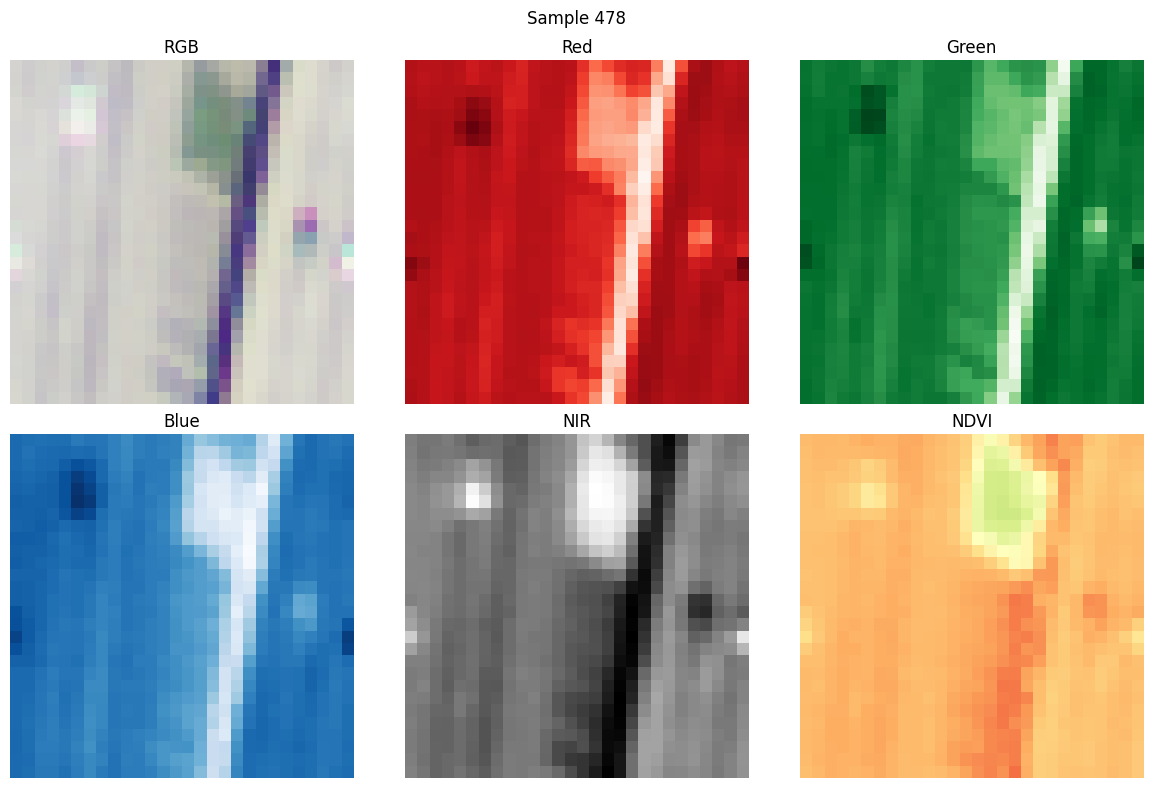

In [94]:
# plot one data sample with a sample_index:
plot_sample_channels(X_test_df, DEFAULT_CONFIG, sample_index=478, has_ndvi=True)

&#x1F479;  _Task:_ Add code to plot a couple of successes and failures (i.e., where predicted labels agree/disagree with the given labels in test_y)

In [67]:
# run experiments

X = add_ndvi(landcover_df, DEFAULT_CONFIG)
y = labels_df.values # Convert labels_df to a NumPy array
channels_df= ("R", "G", "B","NIR","NDVI")
X_train_df, y_train_df, X_test_df, y_test_df = prepare_features(X, y, DEFAULT_CONFIG, channels_df)
n_channels_df= len(channels_df)

print(X.shape)
print(X_train_df.shape)

Train samples: 6000
Test samples:  600
(81000, 3920)
(6000, 3920)


In [68]:
y_pred_df = model_best.predict(X_test_df) # predict a test set

# flatten the one-hot encoding:
class_test_y = np.argmax(y_test_df, axis=1)
class_pred_y = np.argmax(y_pred_df, axis=1)

correct_idx = np.where(class_pred_y == class_test_y)[0]
wrong_idx   = np.where(class_pred_y != class_test_y)[0]
print(f'number of correct predictions: {len(correct_idx)}')
print(f'number of wrong predictions: {len(wrong_idx)}')

number of correct predictions: 566
number of wrong predictions: 34


In [69]:
n_success = 25 # choose n_examples from test set to inspect
n_failure = 25
success_idx = np.random.choice(correct_idx,size=min(n_success, len(correct_idx)),replace=False)
failure_idx = np.random.choice(wrong_idx,size=min(n_failure, len(wrong_idx)),replace=False)
print(failure_idx)

[110 221 450 428 344 121  44 335 571 106 355 478 149  22  68 407 324 183
 379 455 345 380 100  89 561]


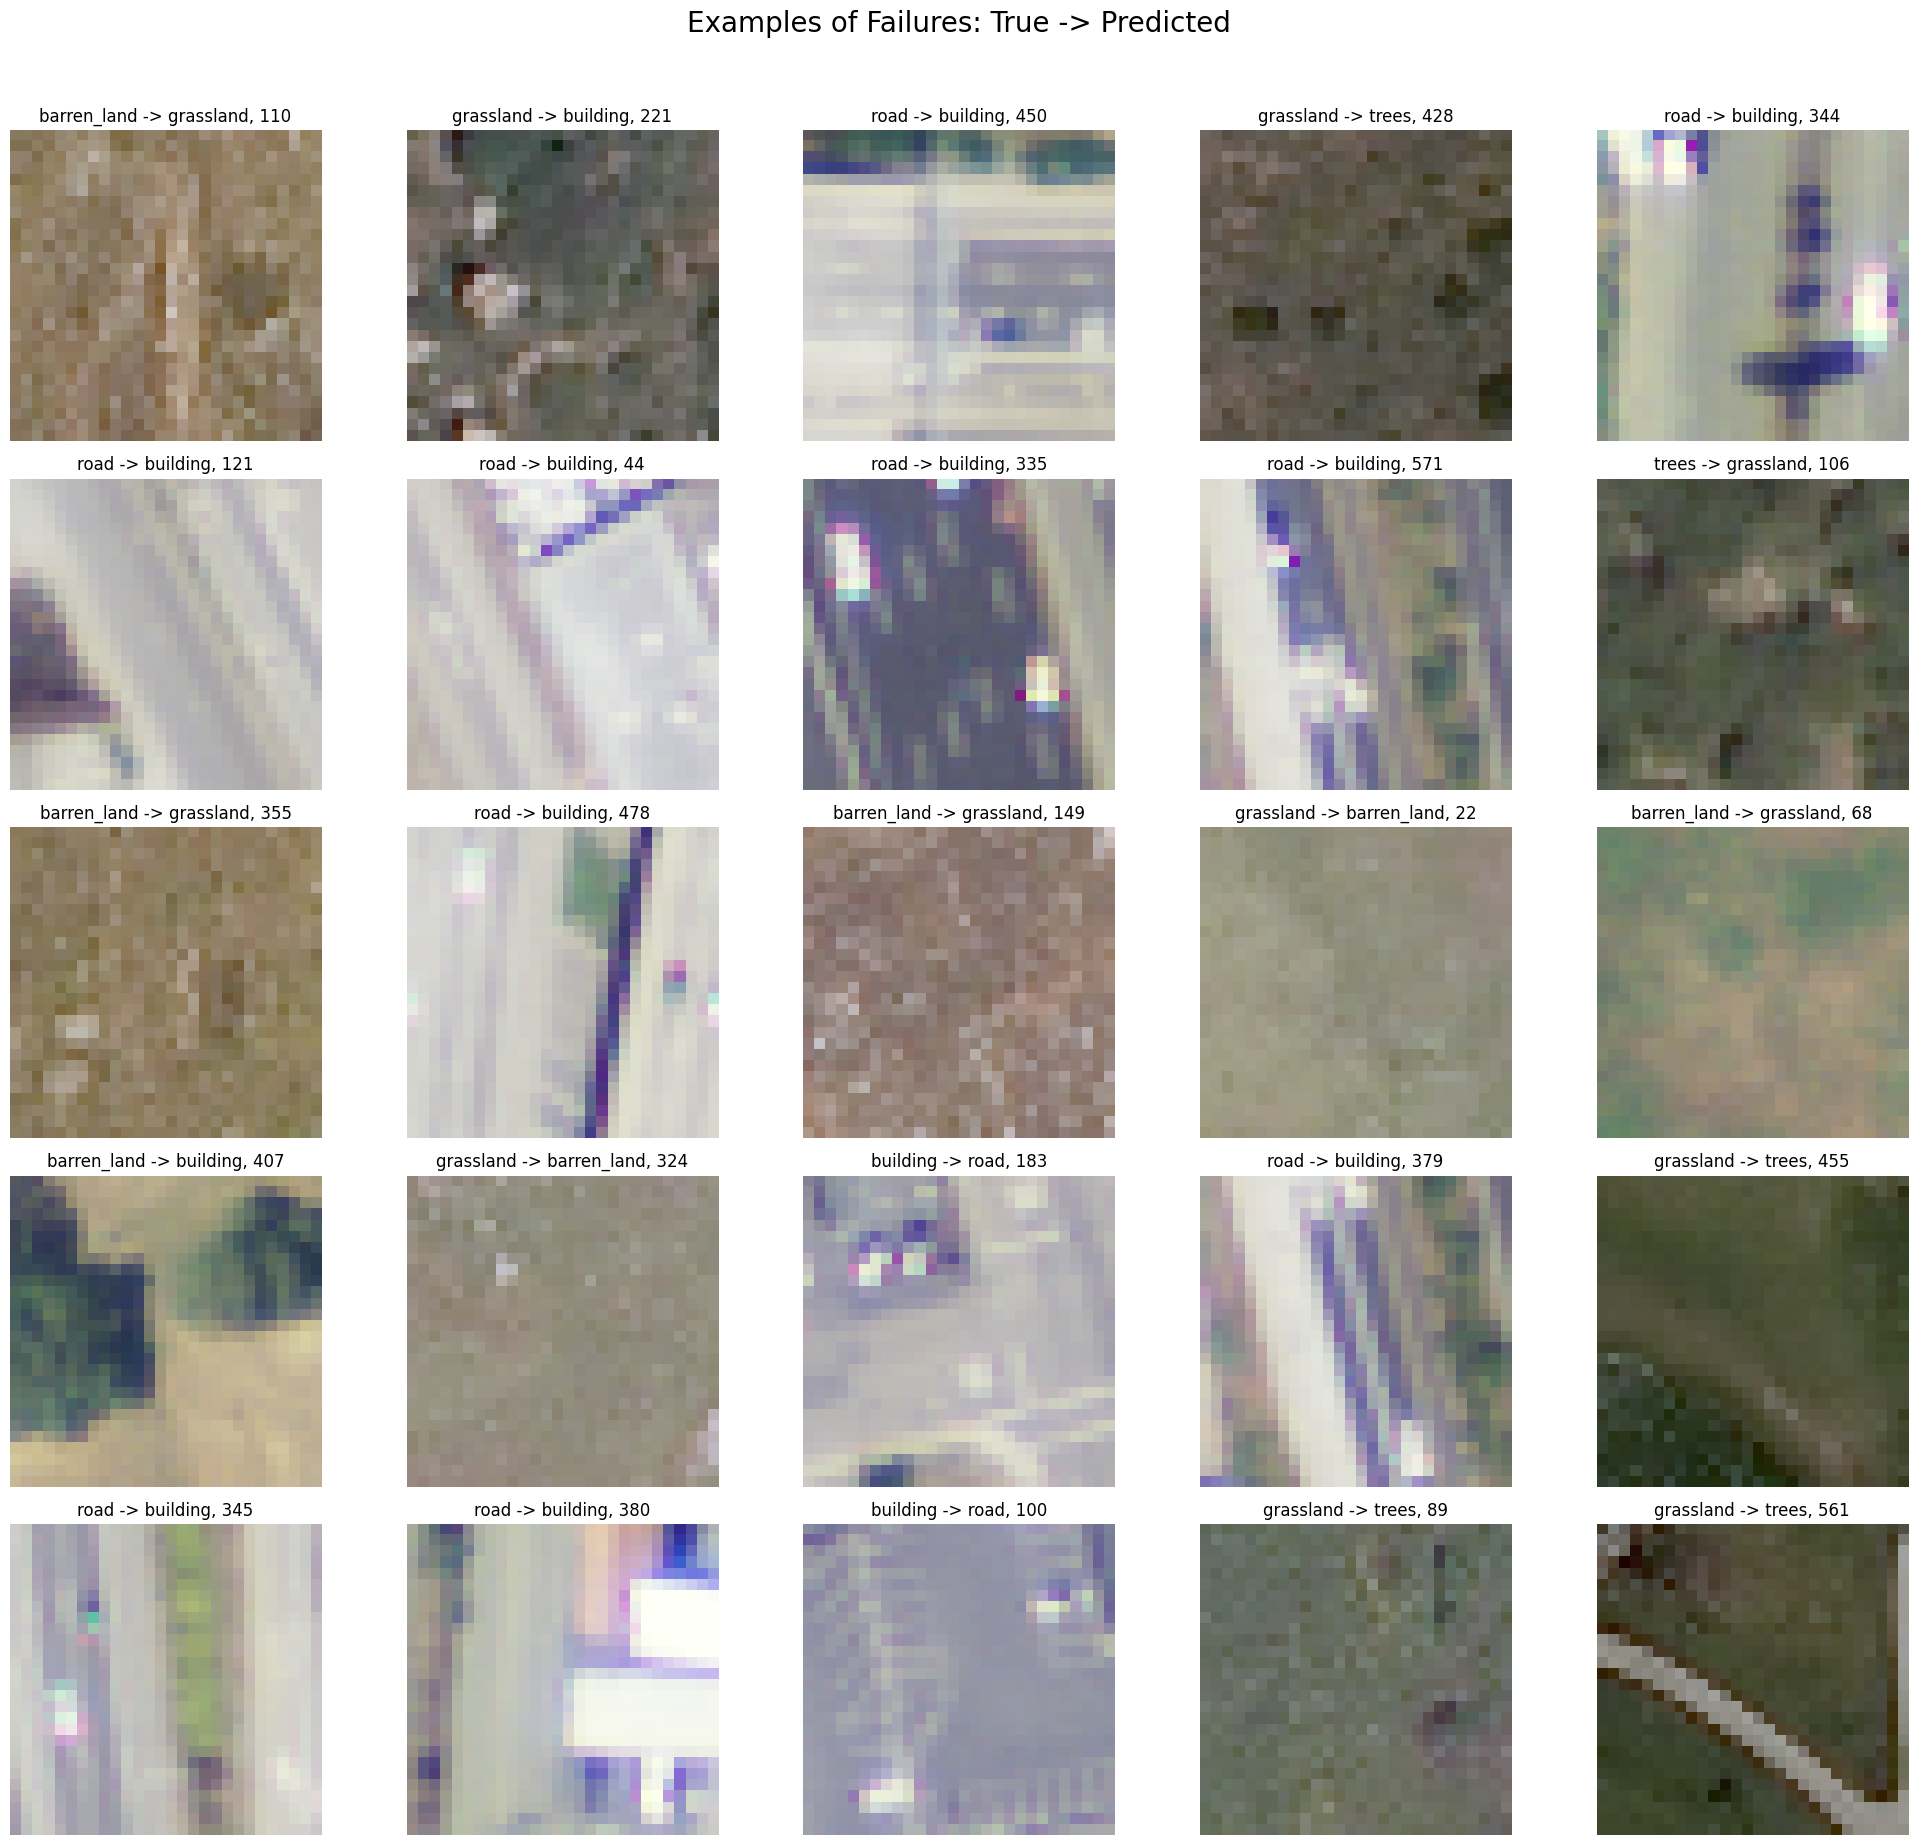

In [70]:
# plot some examples, where prediction failes
fig, ax = plt.subplots(5, 5, figsize=(20, 20)) # for n_success = 25


for k, idx in enumerate(failure_idx):
    row = k // 5
    col = k % 5

    data = np.reshape(X_test_df[idx, :], (-1, 28, 28, n_channels_df))

    ax[row, col].imshow(data[0, ..., :3].astype(np.uint8))
    ax[row, col].set_title(f"{labels[class_test_y[idx]]} -> {labels[class_pred_y[idx]]}, {idx}")
    ax[row, col].axis("off")

fig.suptitle("Examples of Failures: True -> Predicted",fontsize=20,y=0.92)
#plt.tight_layout()
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()